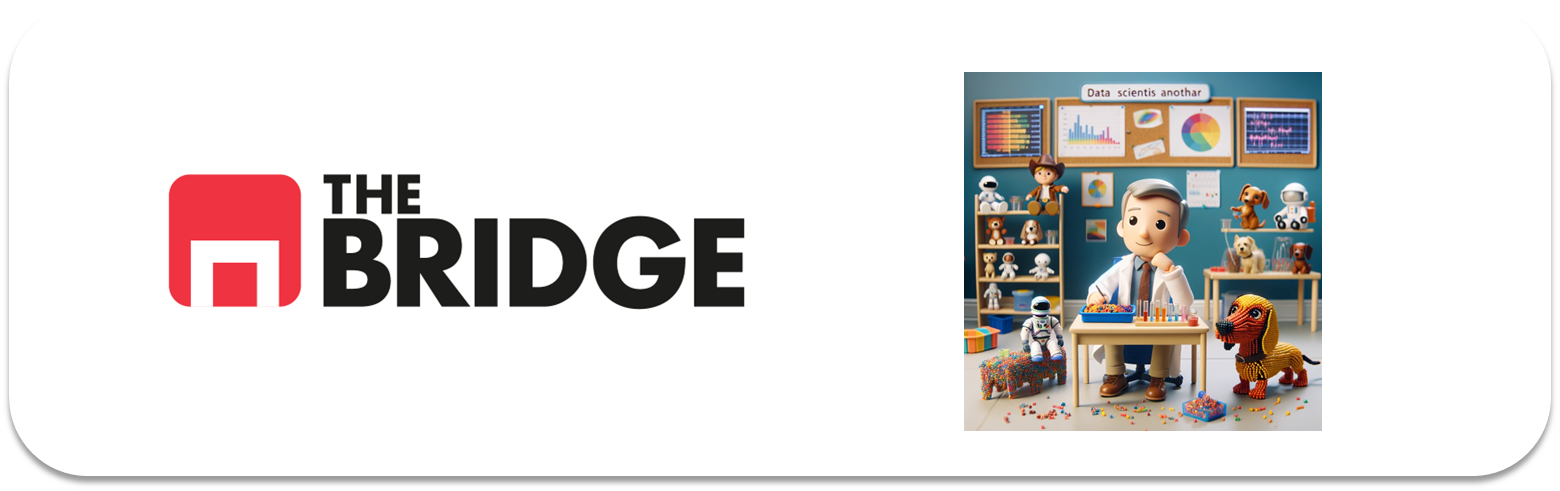

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.options.mode.copy_on_write = True # CoW por defecto a partir de Pandas 3.0.0

In [142]:
# Cargo todas las funciones del archivo de apoyo

from bootcampviztools import pinta_distribucion_categoricas
from bootcampviztools import plot_categorical_relationship_fin
from bootcampviztools import plot_categorical_numerical_relationship
from bootcampviztools import plot_combined_graphs
from bootcampviztools import grafico_dispersion_con_correlacion
from bootcampviztools import plot_grouped_boxplots
from bootcampviztools import plot_grouped_histograms

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [63]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [64]:
df_titanic = sns.load_dataset("titanic")
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [65]:
df_titanic.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [9]:
df_titanic.info() # Hay datos nulos en age, embarked, deck y embarked_town

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [66]:
# Hago una copia del DataFrame y elmino la columna 'parch'

df_titanic2 = df_titanic.copy()
df_titanic2.drop(columns=["parch"], inplace = True)
df_titanic2.head(20)

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [67]:
# Calculo los porcentajes de los nulos en cada columna: (total de valores nulos / total de valores)*100

per_nulos = (df_titanic2.isnull().sum()/len(df_titanic2))*100
per_nulos

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [68]:
# No consigo que el error de COW me deje de dar aunque copio y pego el modo COW para pandas 3.0.0: 
# pd.options.mode.copy_on_write = True
# Y no consigo que me cambie los nulos por la media de edad de su grupo de edad (man, woman y child)

df_titanic_clean = df_titanic2.copy()
df_titanic_clean["age"].fillna(df_titanic_clean.groupby("who")["age"].transform("mean"), inplace = True)

# Elimino la columna deck porque el volumen de valores faltantes es elevadísimo y tampoco aporta mucho
df_titanic_clean.drop(columns=["deck"], inplace = True)

# Y creo una columna nueva con valores booleanos para alive
alive_bool = {'yes': True, 'no': False}
df_titanic_clean["alive_bool"] = df_titanic_clean["alive"].map(alive_bool).astype("bool")

df_titanic_clean.head(20)

C:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Temp\ipykernel_7464\2643566749.py:6: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
When using the Copy-on-Write mode, such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object.


  df_titanic_clean["age"].fillna(df_titanic_clean.groupby("who")["age"].transform("mean"), inplace = True)


,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone,alive_bool
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Southampton,no,False,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,Cherbourg,yes,False,True
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Southampton,yes,True,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,Southampton,yes,False,True
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Southampton,no,True,False
5,0,3,male,NaN,0,8.4583,Q,Third,man,True,Queenstown,no,True,False
6,0,1,male,54.0,0,51.8625,S,First,man,True,Southampton,no,True,False
7,0,3,male,2.0,3,21.0750,S,Third,child,False,Southampton,no,False,False
8,1,3,female,27.0,0,11.1333,S,Third,woman,False,Southampton,yes,False,True
9,1,2,female,14.0,1,30.0708,C,Second,child,False,Cherbourg,yes,False,True


In [69]:
df_titanic_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
 13  alive_bool   891 non-null    bool    
dtypes: bool(3), category(1), float64(2), int64(3), object(5)
memory usage: 73.3+ KB


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| survived | Binario sobre si sobrevivió (1) o no (0) al Titanic |
| sex      | Sexo del pasajero a bordo (male-hombre y female-mujer) |
| age       | Edad del pasajero a bordo |
| sibsp     | Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros) |
| fare      | Precio en libras que pagaron por su pasaje al Titanic |
| embarked     | Es la incial de la letra de la ciudad donde embarcó el pasajero |
| class       | Clase a bordo del barco (Primera, Segunda o Tercera) |
| who       | Si el pasajero era un hombre, una mujer o un niño |
| adult_male    | Identifica si el pasajero es un hombre adulto o por contra en mujer o niño |
| embark_town      | Ciudad en la que embarcó el pasajero dentro del Titanic |
| alive_bool       | True si sobrevivió y False si falleció |
| alone      | True si estaba solo y False si estaba acompañado |




### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

##### <mark>Comentario sobre la pregunta</mark>

- Ya tengo en el dataset una columna que es embark_town con el nombre de cada ciudad. 
- Utilizo esa columna para resolver los análisis. 

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas

In [71]:
df_titanic_clean.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone',
 'alive_bool']

In [54]:
var_cat_titanic = [
    'sex',
    'embarked',
    'class',
    'who',
    'adult_male',
    'embark_town',
    'alive',
    'alone',
    'alive_bool'
]

In [57]:
# Extraemos la moda de todas y cada una de las columnas que son categorías

df_titanic_clean[var_cat_titanic].mode().T


,0
sex,male
embarked,S
class,Third
who,man
adult_male,True
embark_town,Southampton
alive,no
alone,True
alive_bool,False


##### <mark>El retrato robot del pasajero tipo del Titanic</mark> 

- 🤵 Hombre adulto
- 🚢 Pasajero de tercera clase
- 🏦 Embarcó en Southampton
- 🔴 Fallecido durante el hundimiento
- 👨‍👦 Sin acompañante

In [144]:
# Análisis de frecuencias absolutas de las variables categóricas del dataset del Titanic

for var in var_cat_titanic: 
    print(f"Para {var}")
    print(df_titanic_clean[var].value_counts())
    print("\n"*2)

Para sex
sex
male      577
female    314
Name: count, dtype: int64



Para embarked
embarked
S    644
C    168
Q     77
Name: count, dtype: int64



Para class
class
Third     491
First     216
Second    184
Name: count, dtype: int64



Para who
who
man      537
woman    271
child     83
Name: count, dtype: int64



Para adult_male
adult_male
True     537
False    354
Name: count, dtype: int64



Para embark_town
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64



Para alive
alive
no     549
yes    342
Name: count, dtype: int64



Para alone
alone
True     537
False    354
Name: count, dtype: int64



Para alive_bool
alive_bool
False    549
True     342
Name: count, dtype: int64





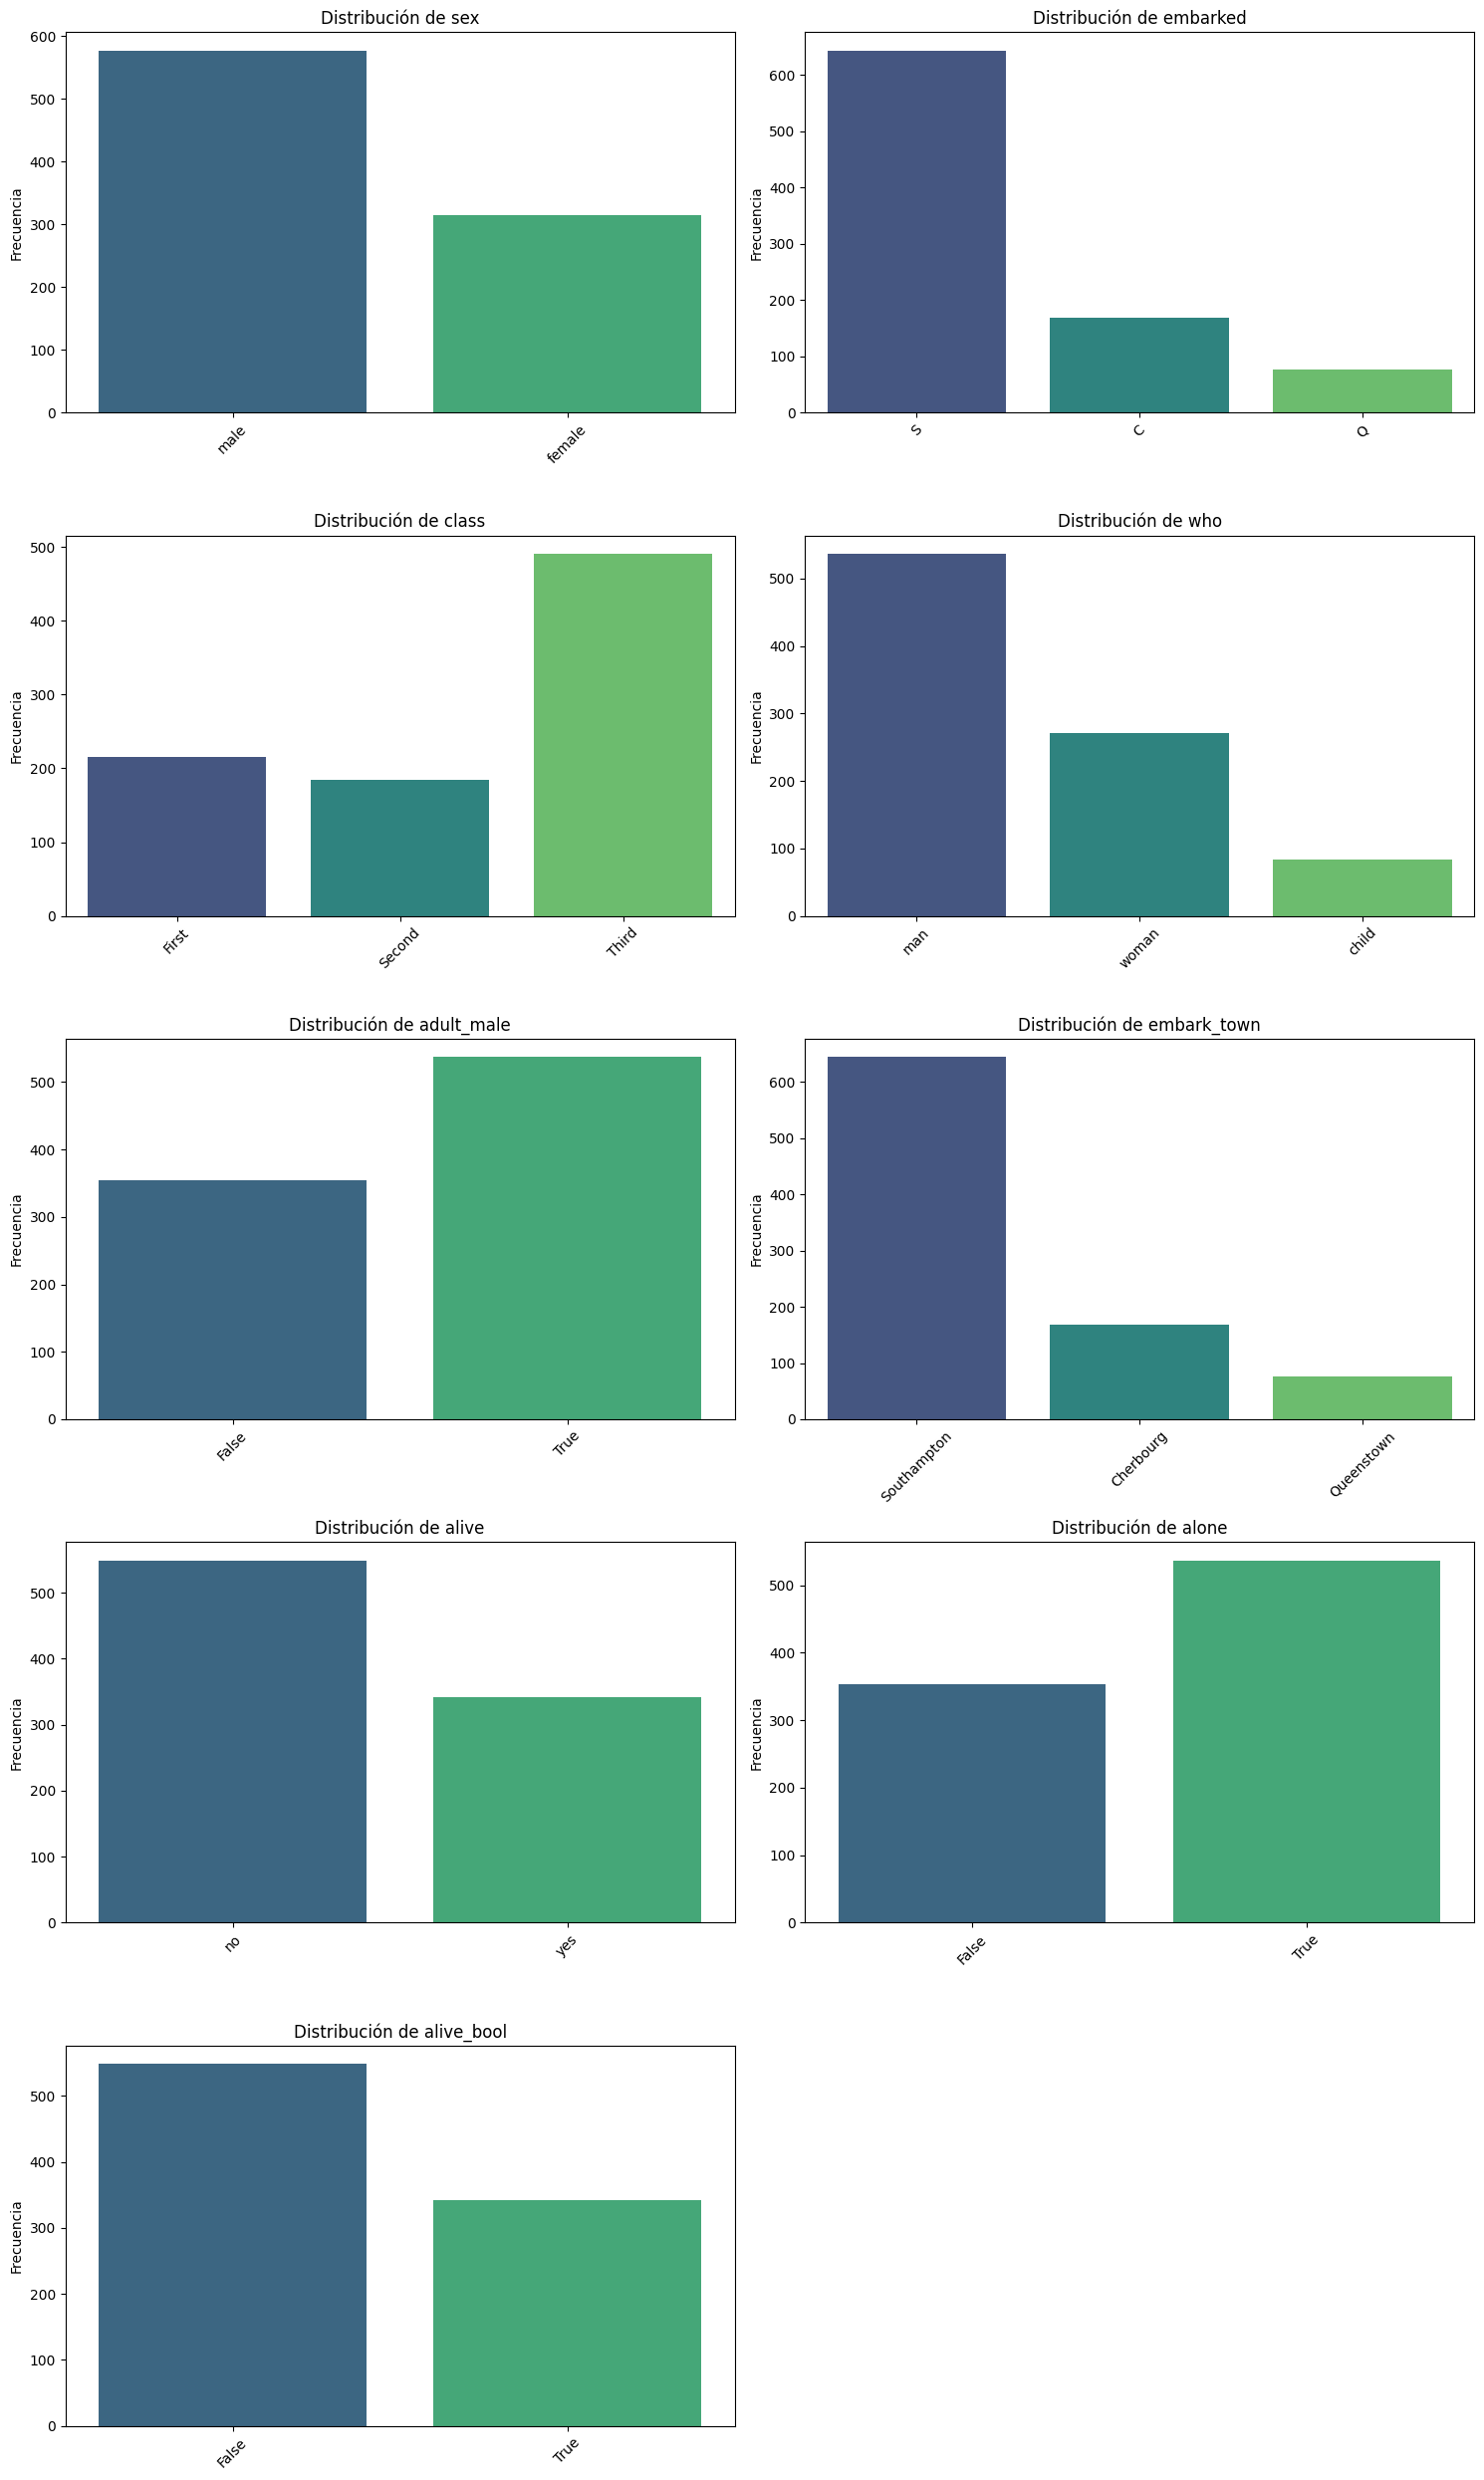

In [143]:
pinta_distribucion_categoricas(df_titanic_clean, var_cat_titanic)

##### <mark>Análisis de la frecuencia absoluta de varias variables</mark>

1. 🤵 El número de hombres a bordo del Titanic era más destacado comparado con mujeres y niños. 
2. 🚢 El pasaje fundamentalmente estaba alojado en tercera clase. Y en primera había más pasajeros que en segunda.
3. 🏦 Southampton fue la ciudad donde más personas embarcaron en el Titanic. Después Cherbourgh y Queenstown.
4. 🔴 Hubo más fallecidos que supervivientes.

In [ ]:
# Ahora vamos a analizar las frecuencias relativas
# Por eso extraemos el reparte porcentual de cada variable

for var in var_cat_titanic: 
    print(f"Para {var}")
    print(df_titanic_clean[var].value_counts()/len(df_titanic_clean)*100)
    print("\n"*2)

Para sex
sex
male      64.758698
female    35.241302
Name: count, dtype: float64



Para embarked
embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64



Para class
class
Third     55.106622
First     24.242424
Second    20.650954
Name: count, dtype: float64



Para who
who
man      60.269360
woman    30.415264
child     9.315376
Name: count, dtype: float64



Para adult_male
adult_male
True     60.26936
False    39.73064
Name: count, dtype: float64



Para embark_town
embark_town
Southampton    72.278339
Cherbourg      18.855219
Queenstown      8.641975
Name: count, dtype: float64



Para alive
alive
no     61.616162
yes    38.383838
Name: count, dtype: float64



Para alone
alone
True     60.26936
False    39.73064
Name: count, dtype: float64



Para alive_bool
alive_bool
False    61.616162
True     38.383838
Name: count, dtype: float64





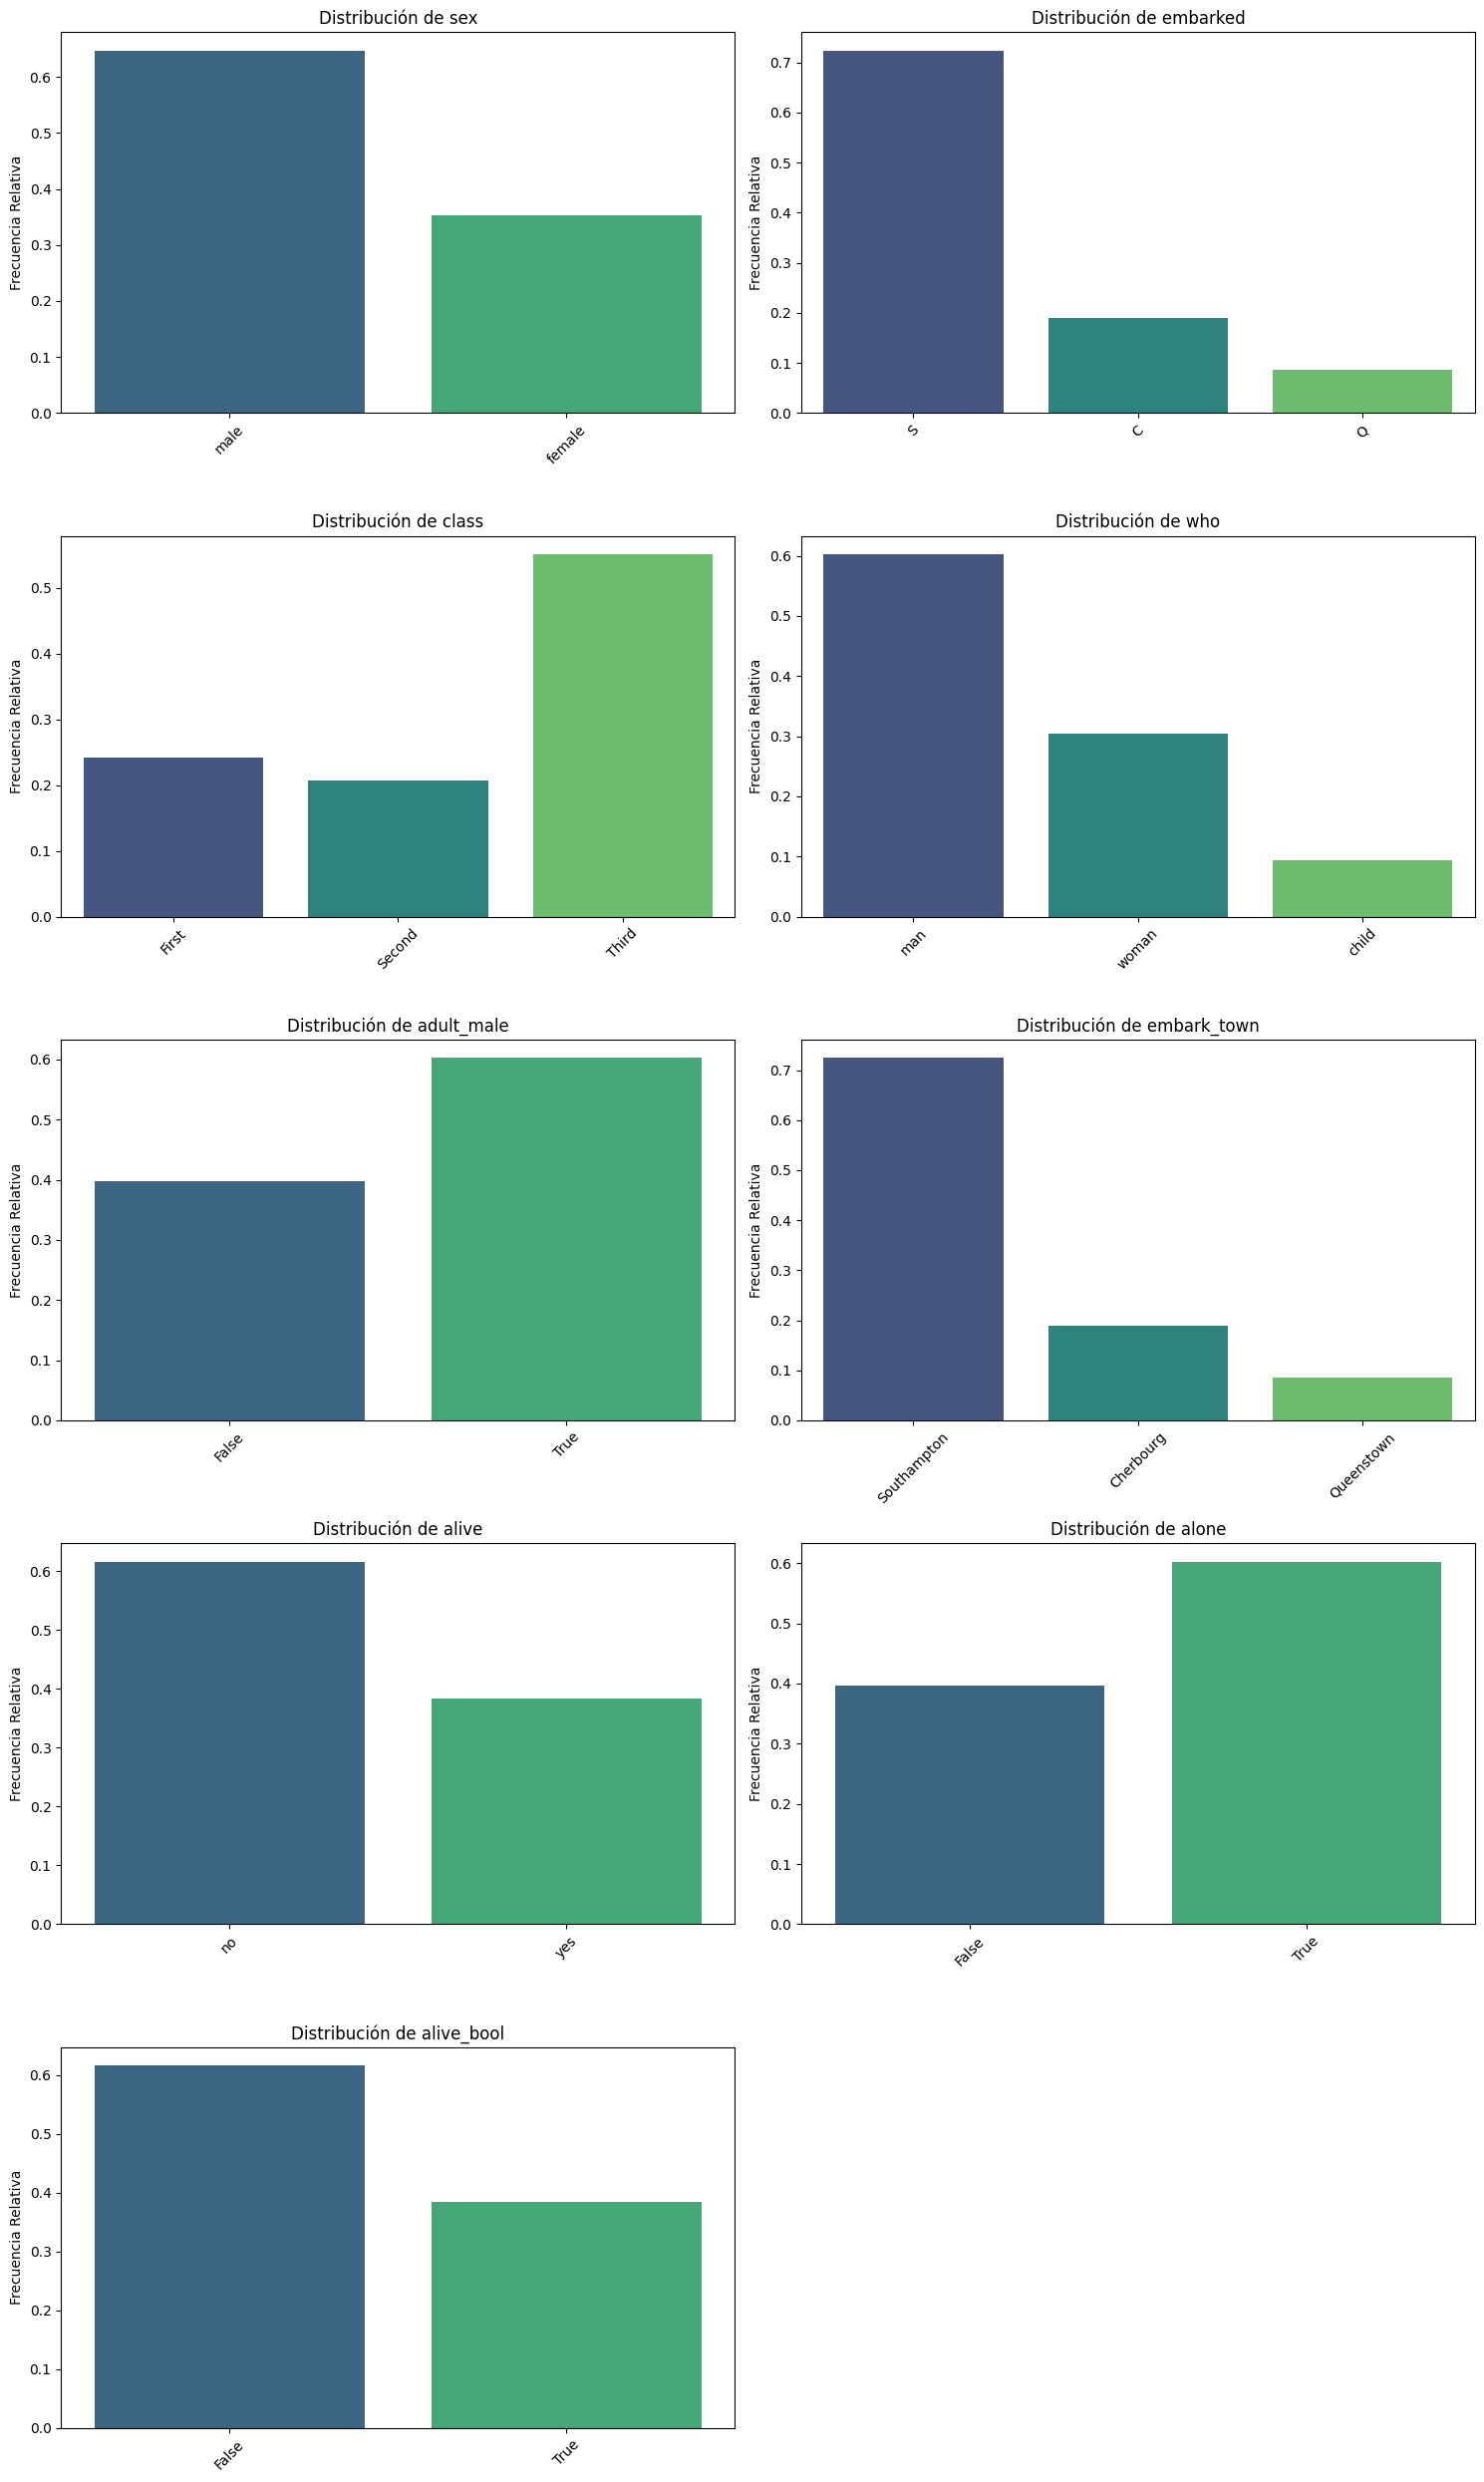

In [73]:
pinta_distribucion_categoricas(df_titanic_clean, var_cat_titanic, relativa = True)

##### <mark>Análisis de la frecuencia absoluta de varias variables</mark>

- 🤵 El número de hombres a bordo del Titanic era más destacado comparado con mujeres y niños. 
1. Con respecto al sexto: 65% hombres y 35% mujeres. 
2. Dentro de ese reparto: el 60% eran hombre adultos, el 30% mujeres adultas y un 10% era menores. 
- 🚢 El pasaje fundamentalmente estaba alojado en tercera clase. El reparto concreto era el siguiente: 
1. En tercera clase esta alojado el 55% del pasaje. 
2. En segunda, el 20% del total de los pasajeros. 
3. En primera se alojaba el 25% de los pasajeros a bordo. 
- 🏦 Southampton fue la ciudad donde más personas embarcaron en el Titanic. Después Cherbourgh y Queenstown.
1. El 72% de los pasajeros embarcaron desde Southampton. 
2. En Cherbourgh lo hizo el 19%.
3. Y en Queenstown lo hizo casi el 9%. 
- 🔴 Hubo más fallecidos que supervivientes. De hecho murió más del 60% del pasaje del Titanic.

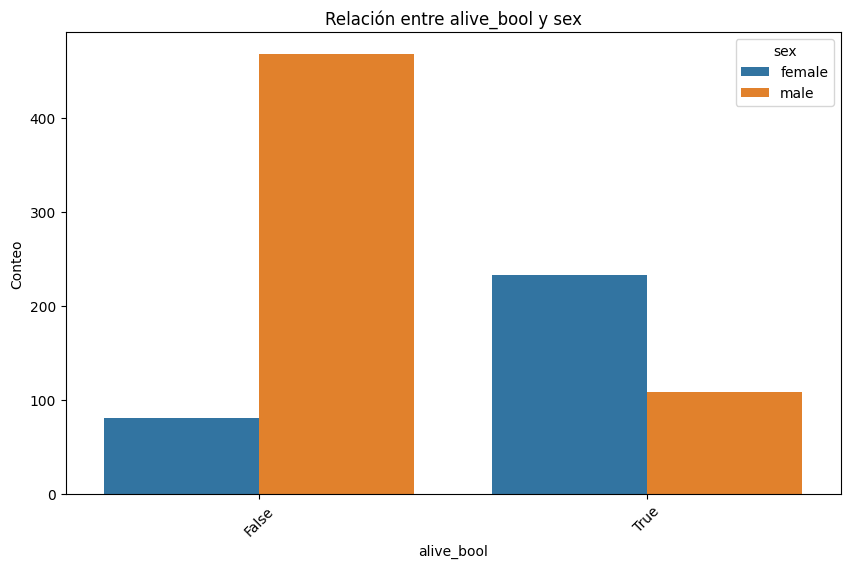

In [ ]:
# Aquí hacemos una comparativa entre el sexo de los pasajeros y si finalmente sobrevivieron al hundimiento 

plot_categorical_relationship_fin(df_titanic_clean, "alive_bool", "sex", relative_freq=False, show_values=False, size_group = 10)

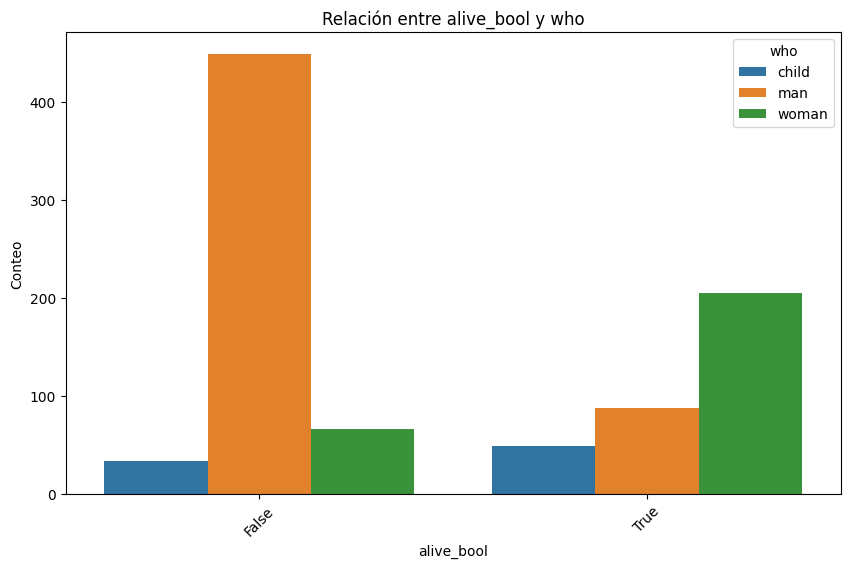

In [ ]:
# Aquí hacemos una comparativa entre tipología de los pasajeros y si finalmente sobrevivieron al hundimiento 

plot_categorical_relationship_fin(df_titanic_clean, "alive_bool", "who", relative_freq=False, show_values=False, size_group = 10)

c:\Users\jcia.ELCONFIDENCIAL\Desktop\DS-bootcamp\ds-bootcamp-juanfcia\03_Data_Analysis\Sprint_07\Unidad_01_Estadistica_Descriptiva_Univariante\03_Practica_Obligatoria\bootcampviztools.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([cat_col1, cat_col2]).size().reset_index(name='count')


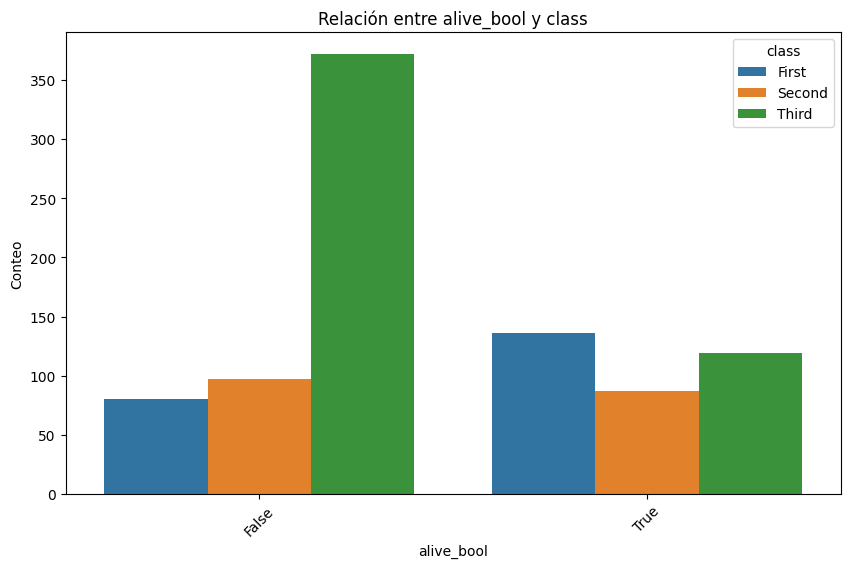

In [ ]:
# Aquí hacemos una comparativa entre el tipo de clase de los pasajeros y si finalmente sobrevivieron al hundimiento 

plot_categorical_relationship_fin(df_titanic_clean, "alive_bool", "class", relative_freq=False, show_values=False, size_group = 10)

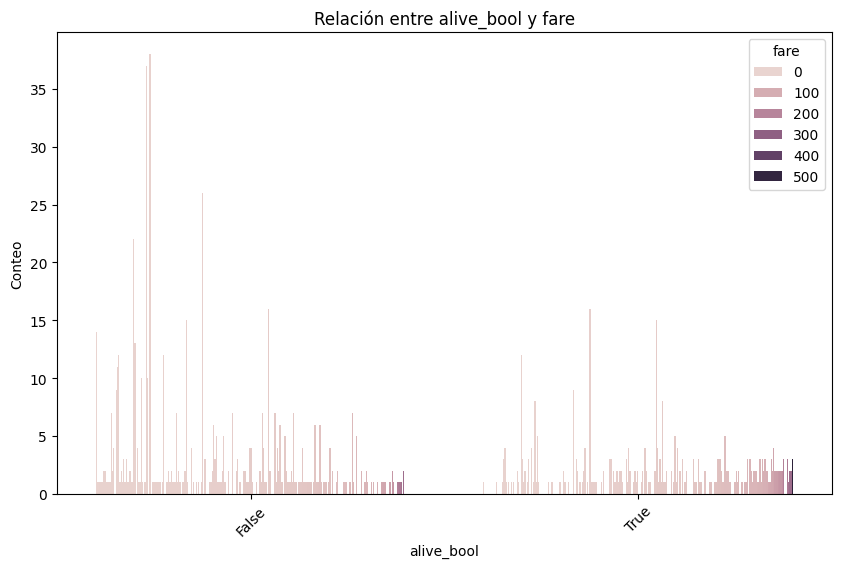

In [ ]:
# Aquí hacemos una comparativa entre el precio del pasaje y si finalmente sobrevivieron al hundimiento 

plot_categorical_relationship_fin(df_titanic_clean, "alive_bool", "fare", relative_freq=False, show_values=False, size_group = 10)

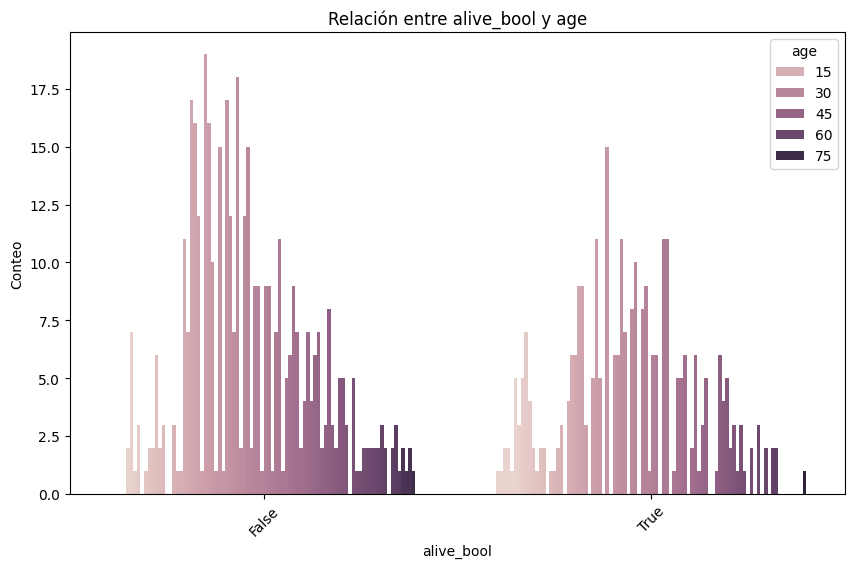

In [159]:
# Aquí hacemos una comparativa entre el tipo de clase de los pasajeros y si finalmente sobrevivieron al hundimiento 

plot_categorical_relationship_fin(df_titanic_clean, "alive_bool", "age", relative_freq=False, show_values=False, size_group = 10)

##### <mark>Análisis de comparativas por pares de las variables categóricas</mark>

- En los datos podemos apreciar que en el Titanic murieron, fundamentalmente, hombres adultos.
- Que si hizo un esfuerzo evidente por salvar del hundimiento a mujeres y niños. 
- Que la clase en la que estabas embarcado fue un elemento determinante: el gran grueso de fallecidos son de tercera clase. 
- Los pasajeros con billetes más caros consiguieron sobrevivir al Titanic. 
- Y por contra, las personas con una edad más avanzada sí que tuvieron más problemas para sobrevivir.   

### #2.2 Numéricas

In [74]:
df_titanic_clean.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone',
 'alive_bool']

In [86]:
# Guardamos en una variable todas las variables numéricas para usarlas en el análisis: 
# Esa variables son la edad de los pasajeros, el precio del pasaje en libras y el número a acompañantes. 

var_num_titanic = [
    'age',
    'sibsp',
    'fare',
]


# Información de porcentajes por cada uno de los valores de cada variable: 

for var in var_num_titanic: 
    print(f"Para {var}")
    print(df_titanic_clean[var].value_counts())
    print("\n"*2)

Para age
age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64



Para sibsp
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64



Para fare
fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64





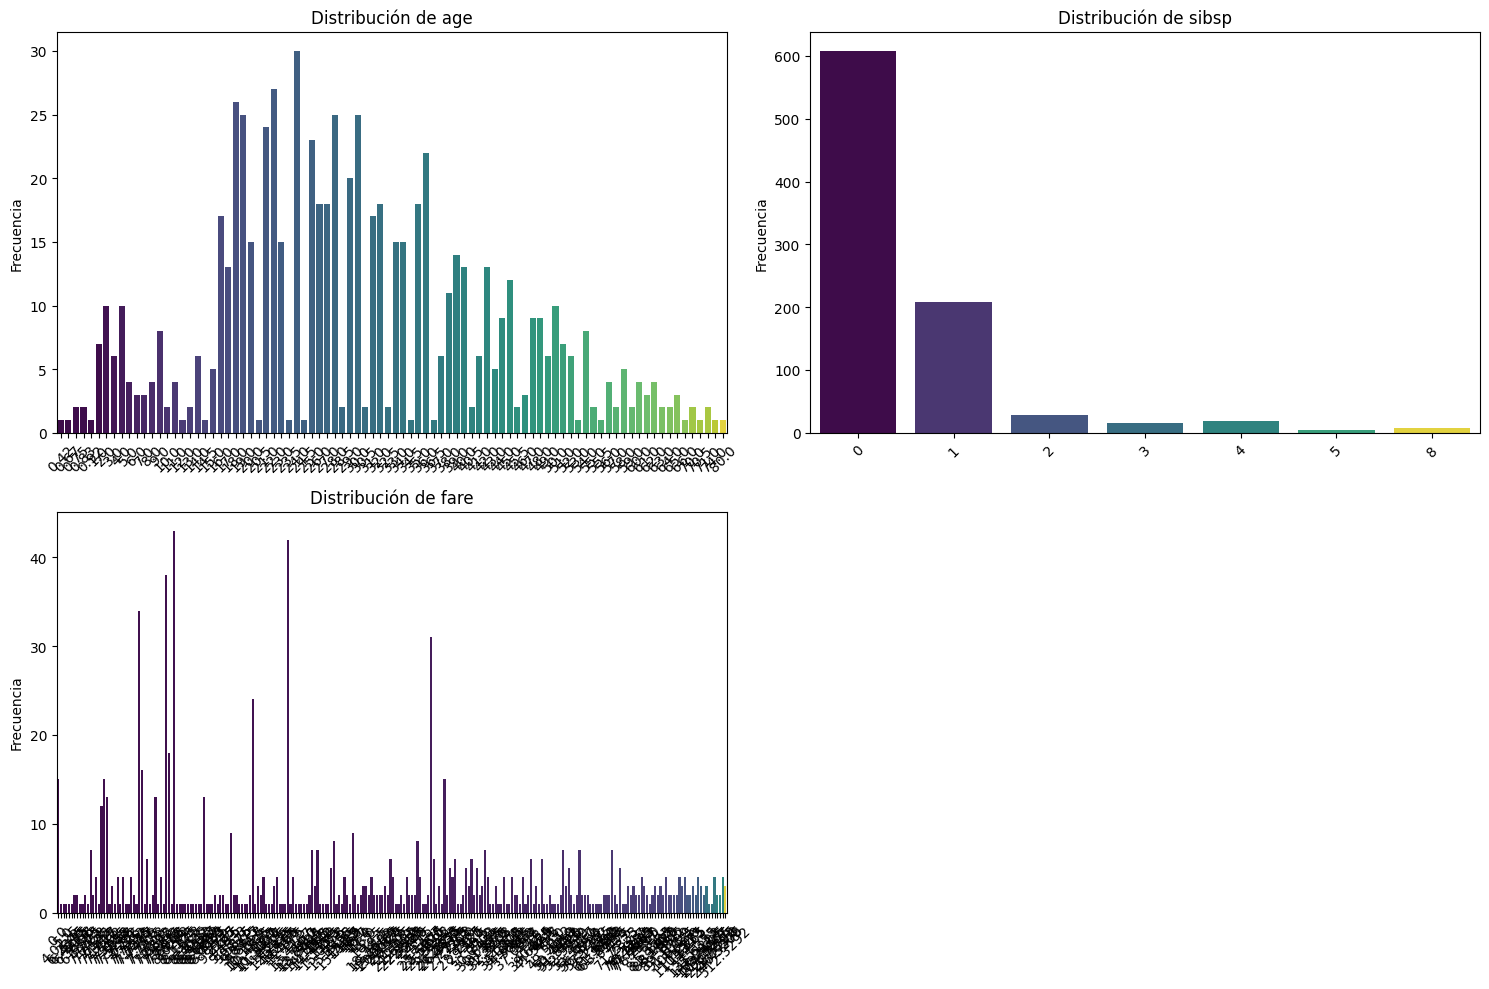

In [77]:
pinta_distribucion_categoricas(df_titanic_clean, var_num_titanic)

##### <mark>Análisis de frecuencias absolutas de las variables numéricas</mark> 

- 👨‍👦 En general las personas a bordo del Titanic iban solas o acompañadas por una o dos personas. 
- 👴 Si nos fijamos en la distribución por edad: 
1. Lógicamente había muy pocas personas mayores, barras de color verde claro y amarillo. 
2. Y pocos niños, aunque más que personas de gran edad. 
3. Esencialmente había pasajeros adultos jóvenes y algo menos de mediana edad. 
- 💰 Sobre el precio de los pasajes: 
1. Es difícil ver en esta gráfica algo destacable, pero se ven seis barras de precios que sobresalen (outliers)

In [85]:
# Información de porcentajes por cada uno de los valores de cada variable: 

for var in var_num_titanic: 
    print(f"Para {var}")
    print(df_titanic_clean[var].value_counts()/len(df_titanic_clean)*100)
    print("\n"*2)

Para age
age
24.00    3.367003
22.00    3.030303
18.00    2.918070
28.00    2.805836
30.00    2.805836
           ...   
24.50    0.112233
0.67     0.112233
0.42     0.112233
34.50    0.112233
74.00    0.112233
Name: count, Length: 88, dtype: float64



Para sibsp
sibsp
0    68.237935
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: count, dtype: float64



Para fare
fare
8.0500     4.826038
13.0000    4.713805
7.8958     4.264871
7.7500     3.815937
26.0000    3.479237
             ...   
13.8583    0.112233
50.4958    0.112233
5.0000     0.112233
9.8458     0.112233
10.5167    0.112233
Name: count, Length: 248, dtype: float64





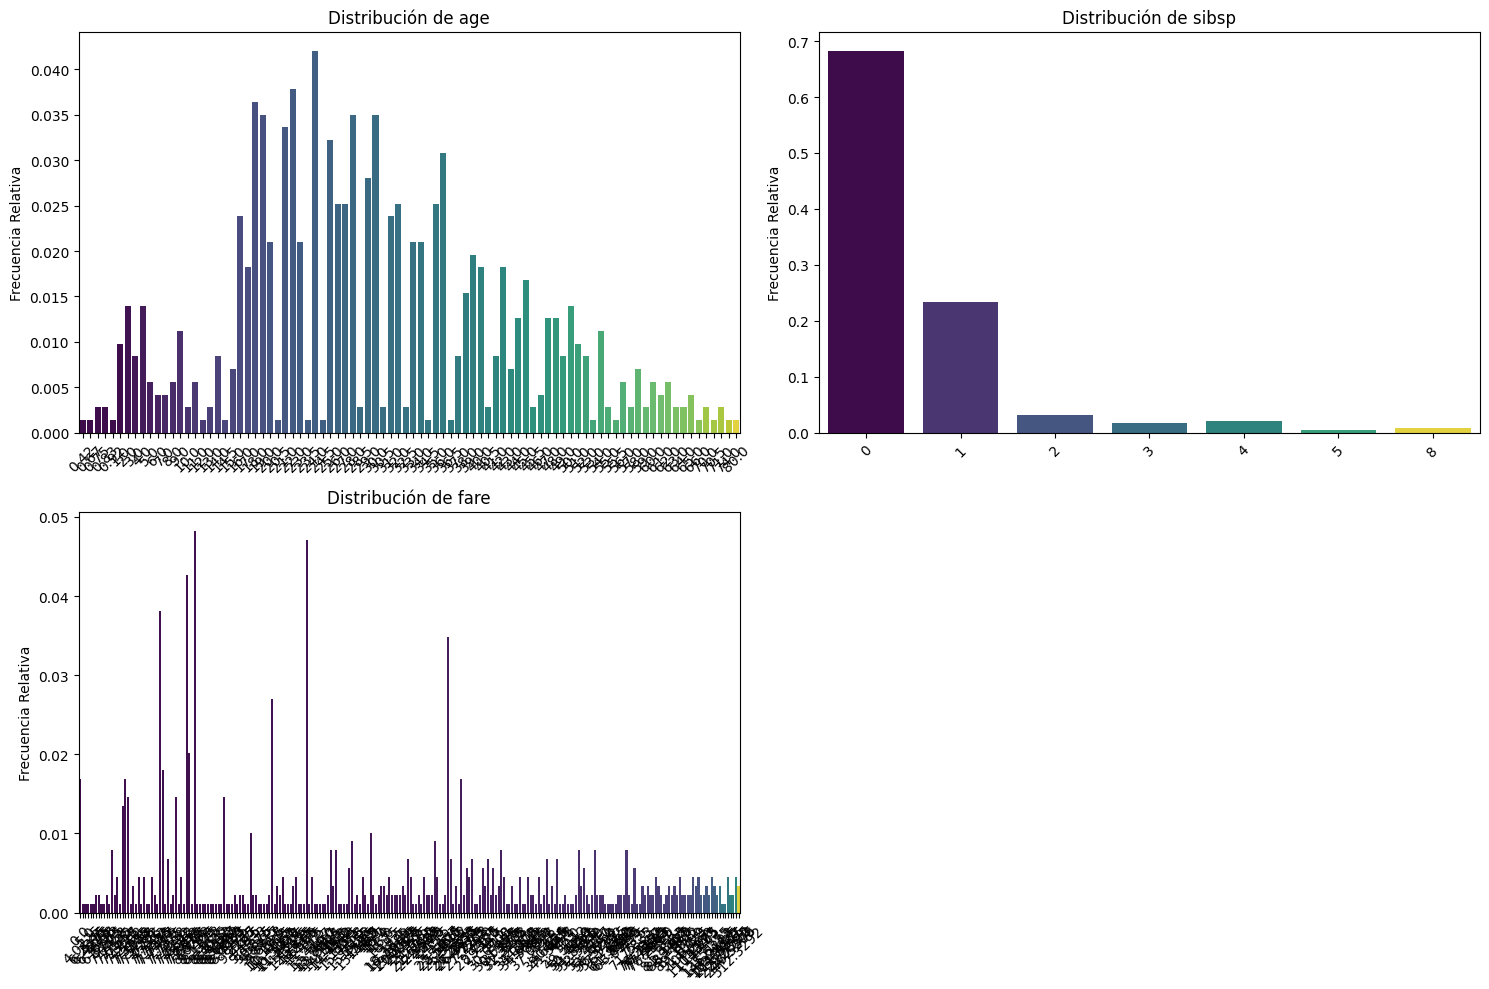

In [80]:
pinta_distribucion_categoricas(df_titanic_clean, var_num_titanic, relativa = True)

In [ ]:
# Busco algunas métricas sobre el precio de los pasajes, para tener información adicional
# El volumen de datos es tan grande que la visualización en gráfico de barra sin clusterizar aporta poco valor. 

df_titanic_clean["fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

In [87]:
# Busco algunas métricas sobre la edad, para tener información adicional
# El volumen de datos es tan grande que la visualización en gráfico de barra sin clusterizar aporta poco valor. 

df_titanic_clean["age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

##### <mark>Análisis de frecuencias absolutas de las variables numéricas</mark> 

- 👴 Si nos fijamos en la distribución por edad: 
1. El promedio de edad entre los pasajeros era de 29 años. 
2. A bordo había, evidentemente, bebés que no alcanzaban un año de edad. 
3. Y el pasajero con más edad tenía 80 años. 
4. Los valores entre los quartiles indica que la mayoría de personas tenían entre 20 y 38 años.  
- 💰 Sobre el precio de los pasajes: 
1. El promedio de precio de todos los pasajes era 32 libras. 
2. El precio más caro, de primera, fue de 512 libras. 
3. Hubo personas que subieron a bordo sin pagar pasaje. 
4. Y la mayoría de precios entre los quartiles estaba entre las 8 y las 31 libras. 

### 📈 Vamos a hacer algunos diagramas de cajas para analizar más en profundidas las variables edad y precio

In [96]:
def plot_multiple_boxplots(df, columns, dim_matriz_visual = 2):
    num_cols = len(columns)
    num_rows = num_cols // dim_matriz_visual + num_cols % dim_matriz_visual
    fig, axes = plt.subplots(num_rows, dim_matriz_visual, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.boxplot(data=df, x=column, ax=axes[i])
            axes[i].set_title(column)

    # Ocultar ejes vacíos
    for j in range(i+1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [95]:
def plot_boxplot_grouped(df, column_to_plot, group_column):
    if df[column_to_plot].dtype in ['int64', 'float64'] and df[group_column].dtype in ['object', 'category']:
        sns.boxplot(data=df, x=group_column, y=column_to_plot)
        plt.show()

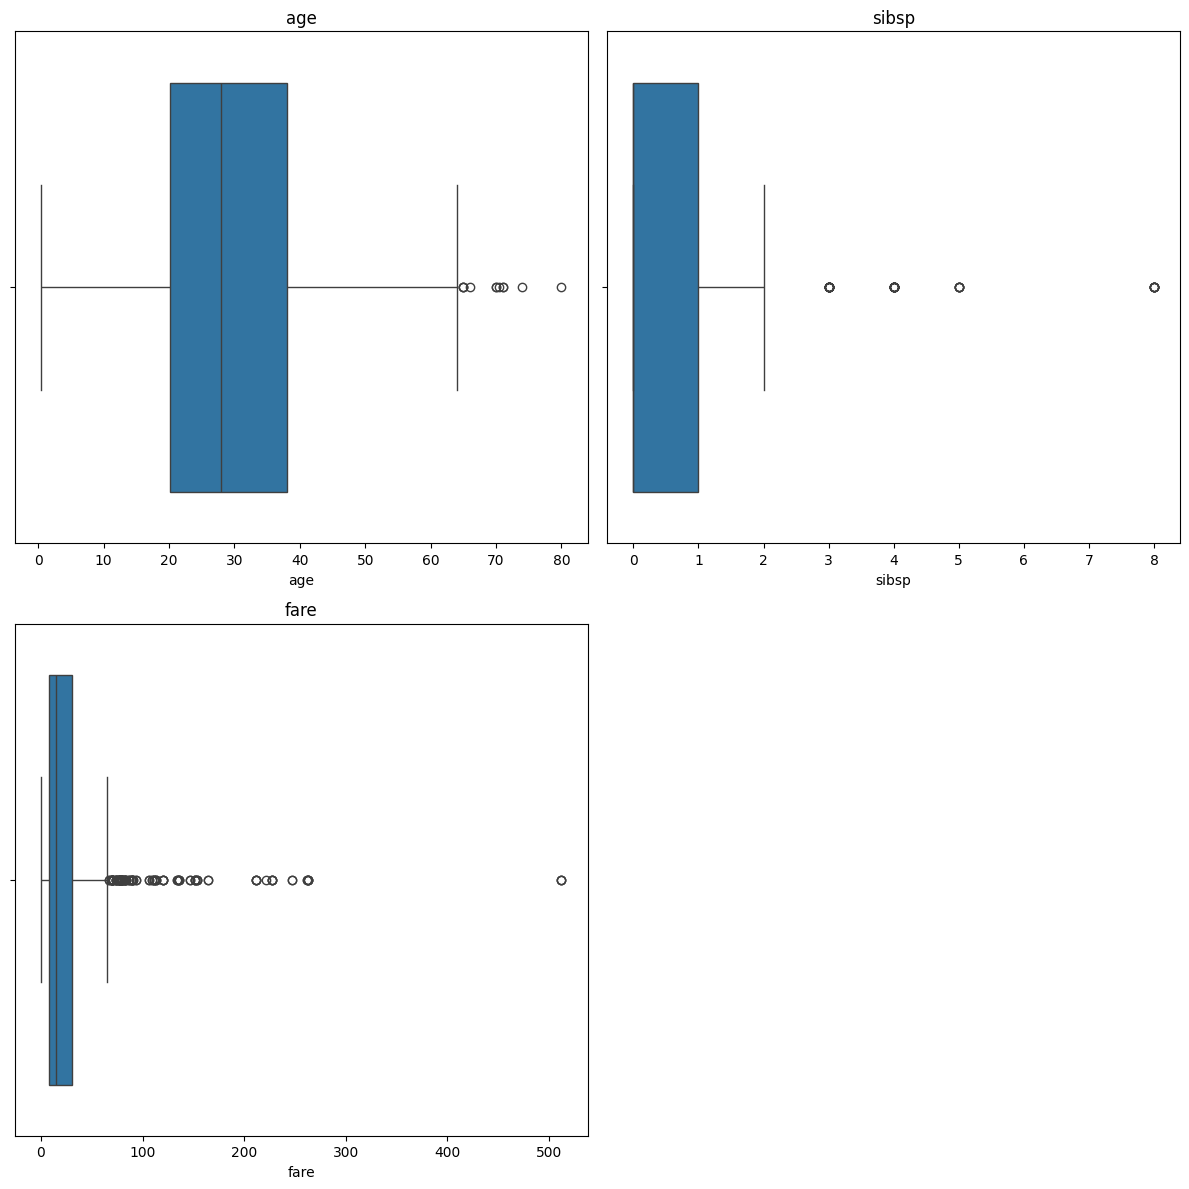

In [93]:
plot_multiple_boxplots(df_titanic_clean, var_num_titanic)

##### <mark>Algunas reflexiones</mark>

1. En edad podemos ver que la mayoría de los pasajeros estaban distribuidos entre los 20 y 40 años. 
2. La gran mayoría de pasajeros iban solos o en pareja. 
3. Los precios tienen mayor variabilidad, pero gran parte de los pasajes estaban por debajo de las 30 libras.
4. Como dato destacable, el pasaje de 512 libras es claramente un valor atípico. 
5. Como curiosidad busqué quién fue la persona que pagó ese precio y encontré [este hilo en Reddit](https://www.reddit.com/r/titanic/comments/163waab/ticket_fare/?tl=es-es).

> *Las suites idénticas en el lado de estribor B51, 53, 55 estaban ocupadas por un banquero de Pensilvania, Thomas Martinez Cardeza, y su madre Lottie, y posiblemente la criada de su madre, Anna Ward. Todo el grupo Cardeza (Thomas, Lottie, Anna y su criado Louis Lesueur) sobrevivieron al hundimiento juntos en el bote salvavidas 3. Thomas Martinez Cardeza pagó poco más de 512 libras por los boletos para él, su madre, su criada y su valet para navegar en esa suite, y ese precio también incluía el camarote B101 que ocupaba su valet. Entonces, aunque se anunciaron a 850, Cardeza fue el único pasajero con boleto que compró la tarifa de esa suite y pagó bastante menos.*
 

(3, 2)


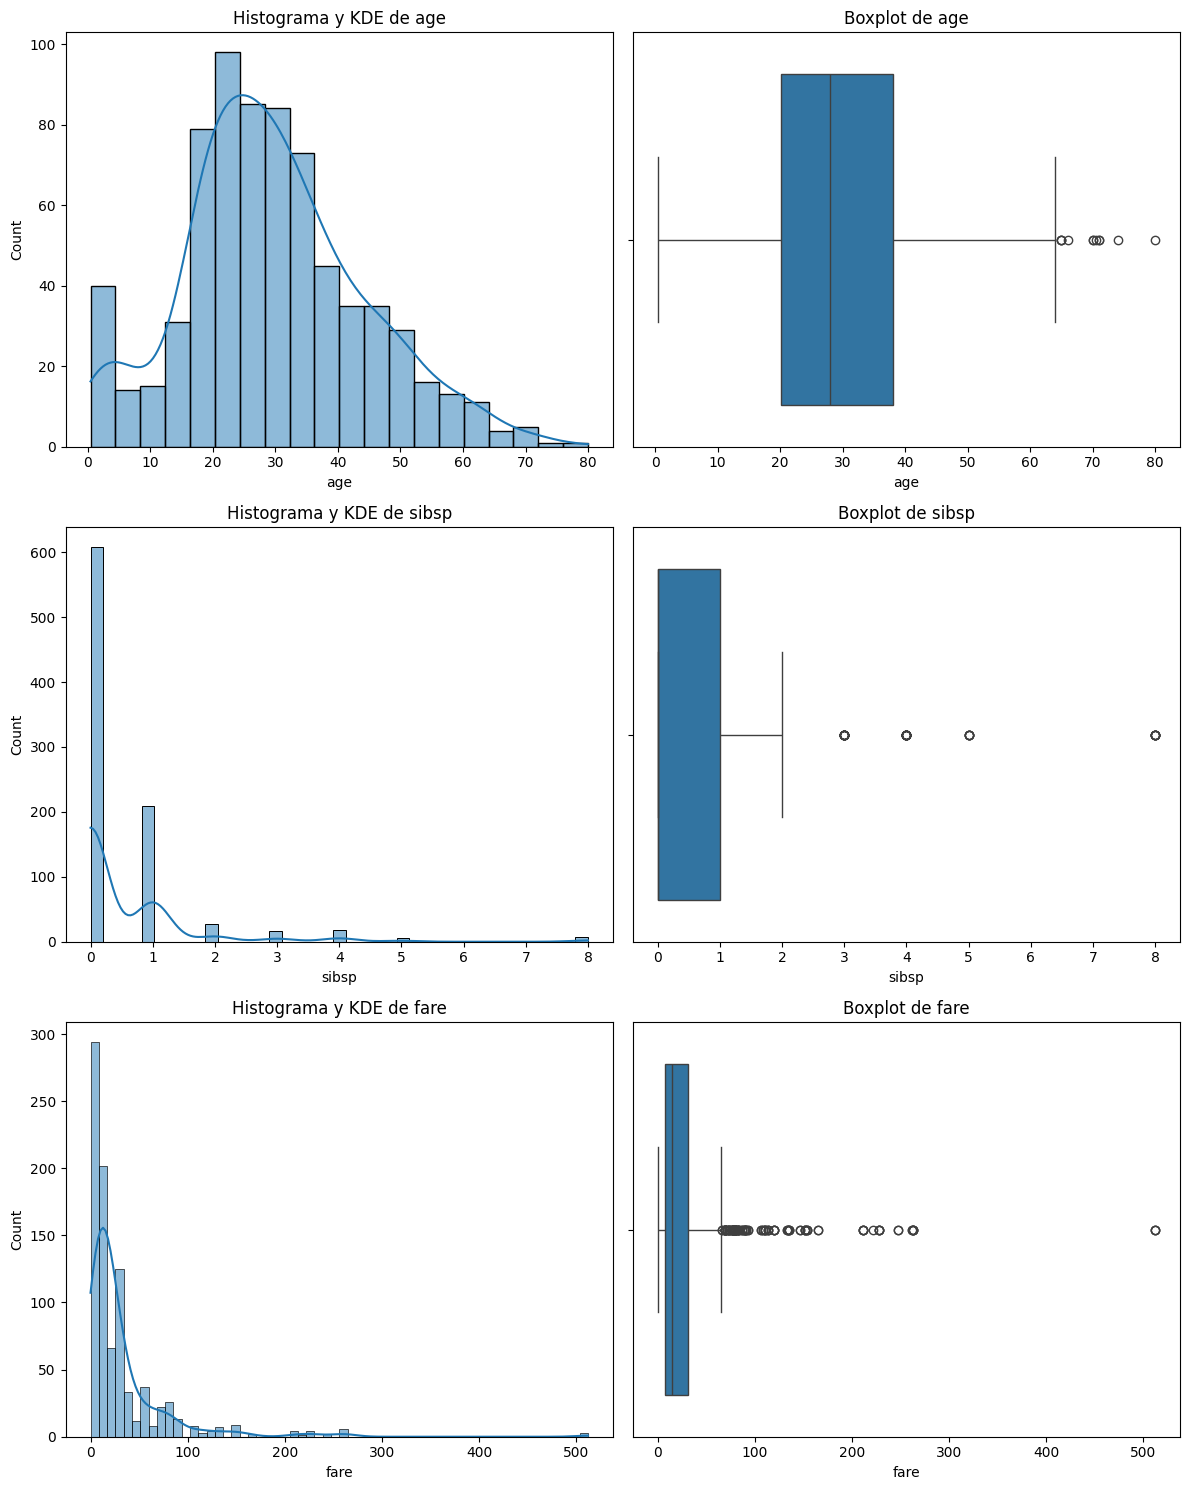

In [166]:
# Aquí hay un gráfico interesante que compara histogramas con variabilidad de la muestra y cómo se comportan los quartiles y valores atípicos:

plot_combined_graphs(df_titanic_clean, var_num_titanic, whisker_width=1.5, bins = None)

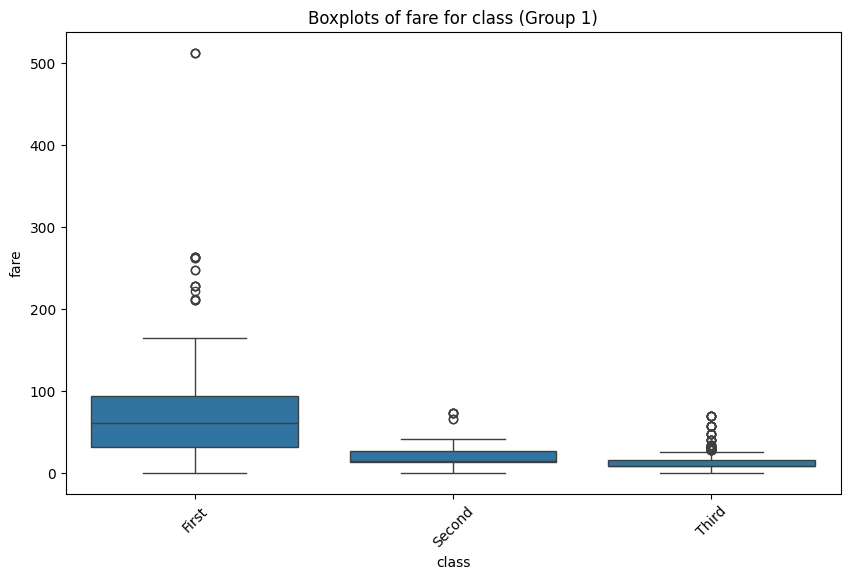

In [ ]:
# Aquí hay una comparativa de valores entre quartiles, medias y valores atípicos entre clase y precio del billete: 

plot_grouped_boxplots(df_titanic_clean, "class", "fare")